In [ ]:
# 线性回归基本实现
%matplotlib inline
import random
import torch
from d2l import torch as d2l

def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    # w: 权重向量，形状为 (特征数,)
    # b: 偏置项，标量
    # num_examples: 生成的样本数量
    # 返回值: 特征矩阵 X 和标签向量 y

    X = torch.normal(0, 1, (num_examples, len(w)))
    # 生成特征矩阵 X，形状为 (num_examples, len(w))
    # torch.normal(0, 1, ...): 从均值为 0、标准差为 1 的正态分布中随机采样
    # len(w): 特征的数量，即权重的维度

    y = torch.matmul(X, w) + b
    # 计算标签 y，形状为 (num_examples,)
    # torch.matmul(X, w): 矩阵乘法，计算 X 和 w 的线性组合
    # + b: 加上偏置项 b

    y += torch.normal(0, 0.01, y.shape)
    # 在标签 y 上添加噪声，使数据更接近真实情况
    # torch.normal(0, 0.01, y.shape): 从均值为 0、标准差为 0.01 的正态分布中采样噪声

    return X, y.reshape((-1, 1))
    # 返回特征矩阵 X 和标签 y
    # y.reshape((-1, 1)): 将 y 的形状从 (num_examples,) 转换为 (num_examples, 1)，方便后续处理

true_w = torch.tensor([2, -3.4])
# 定义真实的权重向量 w，形状为 (2,)
# 这里假设有两个特征，权重分别为 2 和 -3.4

true_b = 4.2
# 定义真实的偏置项 b，标量
features, labels = synthetic_data(true_w, true_b, 1000)

d2l.set_figsize()
# 设置图像的大小

d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);
# 绘制散点图，可视化第二个特征与标签之间的关系
# features[:, (1)]: 取出所有样本的第二个特征（索引为 1）
# .detach().numpy(): 将 PyTorch 张量转换为 NumPy 数组
# labels: 标签数据
# 1: 点的大小


def data_iter(batch_size, features, labels):
    # batch_size: 每个小批量数据的大小
    # features: 输入特征数据，通常是一个二维张量，形状为 (样本数, 特征数)
    # labels: 对应的标签数据，通常是一个一维张量，形状为 (样本数,)
    
    num_examples = len(features)
    # num_examples: 数据集中样本的总数，通过 features 的长度获取

    indices = list(range(num_examples))
    # indices: 生成一个从 0 到 num_examples-1 的索引列表，表示所有样本的索引

    random.shuffle(indices)
    # 将索引列表随机打乱，以便在每个 epoch 中随机读取样本，避免模型学习到数据的顺序信息

    for i in range(0, num_examples, batch_size):
        # 循环遍历数据集，每次取出 batch_size 个样本
        # i 是当前批次的起始索引，每次迭代增加 batch_size

        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        # batch_indices: 当前批次的样本索引
        # indices[i: min(i + batch_size, num_examples)]: 从打乱的索引列表中取出当前批次的索引
        # min(i + batch_size, num_examples): 确保不会超出索引范围，特别是在最后一个批次时

        yield features[batch_indices], labels[batch_indices]
        # yield: 生成器函数的关键字，返回当前批次的特征和标签
        # features[batch_indices]: 根据当前批次的索引取出对应的特征数据
        # labels[batch_indices]: 根据当前批次的索引取出对应的标签数据
        
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break
        
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
# 初始化权重 w
# torch.normal(0, 0.01, size=(2,1)): 从均值为 0、标准差为 0.01 的正态分布中随机采样，生成形状为 (2,1) 的张量
#   - 均值 0: 初始权重集中在 0 附近
#   - 标准差 0.01: 初始权重值较小，避免训练初期梯度爆炸或不稳定
#   - size=(2,1): 权重 w 的形状为 (2,1)，表示有 2 个特征，1 个输出
# requires_grad=True: 表示需要计算梯度，PyTorch 会跟踪对该张量的所有操作，以便后续自动求导
b = torch.zeros(1, requires_grad=True)
# 初始化偏置 b
# torch.zeros(1): 生成形状为 (1,) 的张量，初始值为 0
#   - 偏置 b 通常初始化为 0
# requires_grad=True: 表示需要计算梯度，PyTorch 会跟踪对该张量的所有操作，以便后续自动求导

# 定义模型
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

# 定义损失函数
def squared_loss(y_hat, y):  #@save
    """均方损失"""
     # y_hat: 模型预测值，形状为 (batch_size, 1) 或 (batch_size,)
    # y: 真实标签值，形状为 (batch_size,)
    # 返回每个样本的均方误差，形状与 y_hat 相同
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2  
    # 平方操作放大了较大误差的影响，使得模型更关注较大的错误 
    #将平方误差除以 2，这是为了简化后续梯度计算（求导时会消去系数 2）

# 定义优化算法
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    # params: 模型参数列表（如 w 和 b）
    # lr: 学习率，控制参数更新步长
    # batch_size: 小批量数据大小，用于归一化梯度
    with torch.no_grad():  # 不跟踪梯度计算
        for param in params:  # 遍历每个参数
            param -= lr * param.grad / batch_size  # 更新参数：param = param - lr * (gradient / batch_size)
            param.grad.zero_()  # 梯度清零，避免累积
            
lr = 0.03  # 学习率，控制参数更新的步长
num_epochs = 3  # 训练的总轮数
net = linreg  # 模型定义为线性回归模型
loss = squared_loss  # 损失函数定义为均方误差

# 开始训练,每次迭代称为一个 Step 或 Batch
# 将整个训练数据集中的所有样本都遍历一次，并完成一次参数更新称作epoch
for epoch in range(num_epochs):  # 遍历每一轮训练
    for X, y in data_iter(batch_size, features, labels):  # 遍历小批量数据
        # 计算当前小批量数据的损失
        l = loss(net(X, w, b), y)  # net(X, w, b) 是模型预测值，y 是真实标签
        # l 的形状是 (batch_size, 1)，表示每个样本的损失
        # 将所有样本的损失相加，得到一个标量，然后计算梯度
        # .backward() 是 PyTorch 的自动求导函数，
        # 它会从标量损失开始，沿着计算图反向传播，计算损失函数关于每个参数的梯度
        l.sum().backward()  # 计算损失关于 [w, b] 的梯度
        sgd([w, b], lr, batch_size)  # 使用梯度更新参数 [w, b]

    # 每轮训练结束后，计算整个训练集的损失
    with torch.no_grad():  # 不计算梯度，节省计算资源
        train_l = loss(net(features, w, b), labels)  # 计算整个训练集的损失
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')  # 打印当前轮数的平均损失
        
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

In [ ]:
#线性回归简洁实现，调用库
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

#生成数据集
true_w = torch.tensor([2, -3.4])  # 真实的权重向量
true_b = 4.2  # 真实的偏置项
features, labels = d2l.synthetic_data(true_w, true_b, 1000)  # 生成包含 1000 个样本的合成数据集

# 读取数据集
def load_array(data_arrays, batch_size, is_train=True):  #@save
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)  # 将特征和标签封装为 PyTorch 数据集
    return data.DataLoader(dataset, batch_size, shuffle=is_train)  # 创建数据加载器

batch_size = 10
data_iter = load_array((features, labels), batch_size)   
# 创建数据迭代器
#是一个 DataLoader 对象，用于迭代数据集：
#每次迭代返回一个小批量数据，包含 10 个样本的特征和标签

next(iter(data_iter))  # 将 DataLoader 转换为迭代器并获取第一个小批量数据

# 定义模型
# nn是神经网络的缩写
from torch import nn

# 使用 Sequential 定义一个简单的线性模型
net = nn.Sequential(nn.Linear(2, 1))

#初始化模型参数
net[0].weight.data.normal_(0, 0.01)  # 将权重初始化为均值为 0，标准差为 0.01 的正态分布
net[0].bias.data.fill_(0)  # 将偏置初始化为 0

#定义损失函数  计算均方误差使用的是MSELoss类，也称为平方范数。 默认情况下，它返回所有样本损失的平均值。
loss = nn.MSELoss()  # 使用均方误差损失函数（Mean Squared Error Loss）

#定义优化算法 指定优化的参数以及优化算法所需的超参数字典。 小批量随机梯度下降只需要设置lr值
trainer = torch.optim.SGD(net.parameters(), lr=0.03)  # 使用随机梯度下降（SGD）优化器

#训练
num_epochs = 3  # 训练的总轮数
for epoch in range(num_epochs):  # 遍历每一轮训练
    for X, y in data_iter:  # 遍历小批量数据
        l = loss(net(X), y)  # 计算当前小批量数据的损失
        trainer.zero_grad()  # 清空梯度，避免梯度累积
        l.backward()  # 反向传播，计算梯度
        trainer.step()  # 更新模型参数
    l = loss(net(features), labels)  # 计算整个训练集的损失
    print(f'epoch {epoch + 1}, loss {l:f}')  # 打印当前轮数的损失

w = net[0].weight.data  # 获取训练后的权重
b = net[0].bias.data  # 获取训练后的偏置
print('w的估计误差：', true_w - w.reshape(true_w.shape))
print('b的估计误差：', true_b - b)

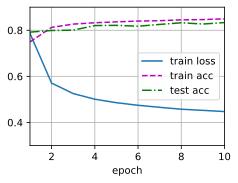

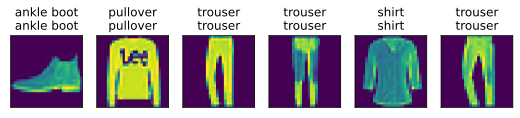

In [2]:
# softmax回归基础实现
import torch
from IPython import display
from d2l import torch as d2l

# 设置批量大小
batch_size = 256  # 每个小批量的大小为 256

# 加载 Fashion-MNIST 数据集
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
# train_iter: 训练数据迭代器
# test_iter: 测试数据迭代器

# 初始化模型参数
num_inputs = 784  # 输入特征数（28x28 图像展平为 784 维向量）
num_outputs = 10  # 输出类别数（Fashion-MNIST 有 10 个类别）

# 初始化权重 W 和偏置 b
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
# W: 权重矩阵，形状为 (784, 10)，从均值为 0，标准差为 0.01 的正态分布中随机初始化
# requires_grad=True: 表示需要计算梯度

b = torch.zeros(num_outputs, requires_grad=True)
# b: 偏置向量，形状为 (10,)，初始化为 0
# requires_grad=True: 表示需要计算梯度

# 定义 softmax 操作
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])  # 示例输入张量
X.sum(0, keepdim=True), X.sum(1, keepdim=True)  # 分别沿维度 0 和维度 1 求和，并保持维度

def softmax(X):
    X_exp = torch.exp(X)  # 对输入 X 的每个元素取指数
    partition = X_exp.sum(1, keepdim=True)  # 沿维度 1 求和，得到每个样本的归一化分母
    return X_exp / partition  # 将指数结果除以归一化分母，应用广播机制

# 定义模型
def net(X):
    # 将输入X重塑为二维张量，其中-1表示自动计算该维度大小，然后与权重矩阵W相乘，加上偏置b，最后通过softmax函数得到概率分布
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

# 定义损失函数前的示例代码，用于展示如何从预测概率分布y_hat中选取真实标签y对应的概率值
y = torch.tensor([0, 2])  # 真实标签
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])  # 预测概率分布
y_hat[[0, 1], y]  # 选取每个样本真实标签对应的预测概率值，即获取了0.1和0.5

# 定义交叉熵损失函数
def cross_entropy(y_hat, y):
    # 计算交叉熵损失，即-log(真实标签对应的预测概率值)
    return - torch.log(y_hat[range(len(y_hat)), y])

# 计算交叉熵损失的示例
cross_entropy(y_hat, y)

# 分类精度计算函数
def accuracy(y_hat, y):  #@save
    """计算预测正确的数量"""
    # 如果y_hat是多维的且最后一维大于1（即有多分类概率），则取概率最大的类别作为预测结果
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    # 比较预测结果和真实标签是否相等，得到布尔型张量
    cmp = y_hat.type(y.dtype) == y
    # 将布尔型张量转换为与y相同数据类型的张量，并求和得到正确预测的数量
    return float(cmp.type(y.dtype).sum())

# 在指定数据集上评估模型精度的函数
def evaluate_accuracy(net, data_iter):  #@save
    """计算在指定数据集上模型的精度"""
    # 如果net是一个PyTorch神经网络模块，则将其设置为评估模式（关闭dropout等，不计算梯度）
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    # 初始化Accumulator对象，用于累加正确预测数和预测总数
    metric = Accumulator(2)  # 正确预测数、预测总数
    # 在不计算梯度的情况下遍历数据集
    with torch.no_grad():
        for X, y in data_iter:
            # 计算模型在当前批次数据上的预测结果，并计算该批次数据的精度和样本数，累加到metric中
            metric.add(accuracy(net(X), y), y.numel())
    # 返回总的正确预测数除以总的预测数，得到模型在数据集上的精度
    return metric[0] / metric[1]

# 定义一个Accumulator类，用于在n个变量上进行累加操作
class Accumulator:  #@save
    """在n个变量上累加"""
    def __init__(self, n):
        # 初始化一个长度为n的列表，所有元素初始值为0.0，用于存储累加的变量值
        self.data = [0.0] * n

    def add(self, *args):
        # 将传入的参数args与self.data中的值逐一相加，并更新self.data
        # args应该是一个长度与self.data相同的元组，每个元素对应一个要累加的量
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        # 将self.data中的所有元素重置为0.0，用于重新开始累加
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        # 通过索引访问self.data中的元素
        return self.data[idx]

# 定义一个训练模型一个迭代周期的函数
def train_epoch_ch3(net, train_iter, loss, updater):  #@save
    """训练模型一个迭代周期"""
    # 如果net是一个PyTorch神经网络模块，则将其设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 初始化一个Accumulator对象，用于累加训练损失总和、训练准确度总和、以及样本数
    metric = Accumulator(3)
    # 遍历训练数据集
    for X, y in train_iter:
        # 通过模型计算预测结果
        y_hat = net(X)
        # 计算损失
        l = loss(y_hat, y)
        # 根据updater的类型，执行不同的梯度清零和参数更新操作
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置的优化器时，先清零梯度，然后计算损失的均值并反向传播，最后更新参数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用自定义优化器时，直接计算损失的总和并反向传播，然后调用updater函数更新参数
            # 这里假设updater函数接受一个批量大小作为参数，用于调整学习率等（具体取决于updater的实现）
            l.sum().backward()
            updater(X.shape[0])
        # 累加训练损失总和、训练准确度总和、以及当前批量的样本数到metric中
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 计算并返回整个训练迭代周期的平均损失和平均准确度
    # 注意：这里使用l.sum()而不是l.mean()来累加损失，因为前面在自定义优化器路径中计算的是总和
    # 而在PyTorch优化器路径中虽然计算的是均值，但我们在adder中再次对其进行了求和，所以最终结果是正确的总和
    # 然后通过除以总样本数来得到平均损失和平均准确度
    return metric[0] / metric[2], metric[1] / metric[2]

# 定义一个Animator类，用于在动画中绘制数据
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 初始化Animator对象，设置图表的标签、限制、比例、线条格式等
        if legend is None:
            legend = []  # 如果没有提供图例，则默认为空列表
        d2l.use_svg_display()  # 使用SVG格式显示图表
        # 创建一个图形和一组子图（axes），子图的数量由nrows和ncols决定
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        # 如果只创建了一个子图，则将self.axes转换为列表以便后续迭代
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数创建一个配置子图属性的闭包，以便后续调用
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        # 初始化用于存储X和Y数据的列表，以及线条格式列表
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加数据点并更新图表
        # 如果y不是列表或数组，则将其转换为只包含一个元素的列表
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)  # y中元素的数量
        # 如果x不是列表或数组，则创建一个与y长度相同的列表，每个元素都是x
        if not hasattr(x, "__len__"):
            x = [x] * n
        # 如果self.X和self.Y还未初始化，则进行初始化
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        # 遍历x和y，将数据添加到对应的列表中
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        # 清除当前子图的内容，以便绘制新的数据
        self.axes[0].cla()
        # 遍历存储的数据和线条格式，绘制多条线
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        # 配置子图的属性（如标签、限制等）
        self.config_axes()
        # 显示更新后的图表，并清除之前的输出
        display.display(self.fig)
        display.clear_output(wait=True)

# 定义一个训练模型的函数
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """训练模型"""
    # 创建一个Animator对象，用于绘制训练过程中的损失和准确率
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    # 遍历指定的训练轮数
    for epoch in range(num_epochs):
        # 训练模型一个迭代周期，并返回训练和测试指标
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)  # 计算测试集的准确率
        # 向Animator对象中添加数据，更新图表
        animator.add(epoch + 1, train_metrics + (test_acc,))
    # 解包训练指标（损失和准确率）
    train_loss, train_acc = train_metrics
    # 断言训练损失、训练准确率和测试准确率满足一定的条件。在代码执行过程中检查某个条件是否为真。
    # 如果这些条件不满足（即为假），程序将抛出一个AssertionError异常，并显示指定的错误信息
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

# 定义一个更新模型参数的函数（使用小批量随机梯度下降）
lr = 0.1  # 学习率
def updater(batch_size):
    # 返回一个更新函数，该函数接受模型参数和小批量数据，并更新参数
    return d2l.sgd([W, b], lr, batch_size)

# 设置训练轮数
num_epochs = 10
# 训练模型
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

# 定义一个预测标签的函数
def predict_ch3(net, test_iter, n=6):  #@save
    """预测标签"""
    # 从测试数据集中获取一批数据
    for X, y in test_iter:
        break
    # 获取真实的标签和预测的标签
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    # 创建标题列表，每个标题包含真实标签和预测标签
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    # 显示图像和标题
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

# 使用训练好的模型进行预测
predict_ch3(net, test_iter)

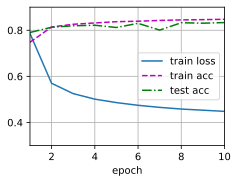

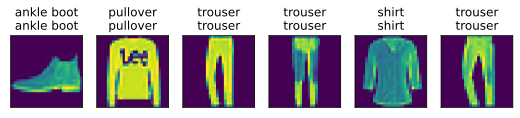

In [3]:
# sofamax回归简洁实现
import torch
from torch import nn
from d2l import torch as d2l

# 设置批量大小
batch_size = 256  # 每个小批量的大小为 256

# 加载 Fashion-MNIST 数据集
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
# train_iter: 训练数据迭代器
# test_iter: 测试数据迭代器

# 定义模型
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))
# nn.Sequential: 按顺序组合多个网络层
# nn.Flatten(): 展平层，将输入从二维张量（28x28）转换为一维张量（784）
# nn.Linear(784, 10): 全连接层，输入大小为 784，输出大小为 10（对应 10 个类别）

# 初始化模型权重
def init_weights(m):
    if type(m) == nn.Linear:  # 如果是线性层
        nn.init.normal_(m.weight, std=0.01)  # 使用均值为 0，标准差为 0.01 的正态分布初始化权重

net.apply(init_weights)  # 对模型的每一层应用 init_weights 函数

# 定义损失函数
loss = nn.CrossEntropyLoss(reduction='none')  # 使用交叉熵损失函数，reduction='none' 表示不汇总损失
# nn.CrossEntropyLoss: 适用于分类任务的损失函数
# reduction='none': 返回每个样本的损失，而不是汇总为一个标量

# 定义优化算法
trainer = torch.optim.SGD(net.parameters(), lr=0.1)  # 使用随机梯度下降（SGD）优化器
# net.parameters(): 获取模型的所有参数（权重和偏置）
# lr=0.1: 学习率为 0.1

# 训练模型
num_epochs = 10  # 训练的总轮数为 10
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)  # 调用训练函数
# net: 模型
# train_iter: 训练数据迭代器
# test_iter: 测试数据迭代器
# loss: 损失函数
# num_epochs: 训练轮数
# trainer: 优化器

# 预测
def predict_ch3(net, test_iter, n=6):  #@save
    """预测标签（定义见第3章）"""
    for X, y in test_iter:  # 从测试数据迭代器中获取一个小批量数据
        break
    trues = d2l.get_fashion_mnist_labels(y)  # 获取真实标签的文本描述
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))  # 获取预测标签的文本描述
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]  # 组合真实标签和预测标签
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])  # 显示前 n 个样本的图像和标签

predict_ch3(net, test_iter)  # 调用预测函数